# Dynamic Time Warping similarities on SPY monthly price paths

Exploratory notebook applying Dynamic Time Warping (DTW) and K-medoids clustering to monthly SPY price paths. The goal is to compare the shapes of historical monthly trajectories after indexing each month to its first available price.


## Build a dataframe where each row is a daily time series

In [815]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import yfinance as yf
import random

In [538]:
df = yf.download('SPY', start='1980-02-01', end='2022-04-08')
df['Year_Month']= df.index.year.map(str)+ '_'+ df.index.month.map(str)
df.drop(['Open', 'High', 'Low', 'Close', 'Volume'], axis=1, inplace=True)
# Keep groups in chronological order.
df['Year_Month']= [el.split('_')[0]+'_0'+el.split('_')[1] if (len(el.split('_')[1])==1) else el for el in df['Year_Month'] ]

dft=df.groupby('Year_Month')
groupings = list(dft.groups.keys())  # Month labels.
daily_month_prices=[]
for i, gkey in enumerate(groupings, 1):
    group = dft.get_group(gkey)
    daily_month_prices.append(group['Adj Close'].values)  # Append values so each array becomes one row.

df=pd.DataFrame(daily_month_prices)  # Build a dataframe where each row is one period-level time series.
df.set_index([groupings], inplace=True)
df.rename(columns={0: "First_day"}, inplace=True)
df#/ df['First_day']
df= df.div(df.First_day, axis=0) # Normalize each row by the first available price of the month.
df.drop(df.head(1).index,inplace=True) # Drop the first row.
df.drop(df.tail(1).index,inplace=True) # Drop the last row.
# Additional rows with too many missing values may still be present.
# Delete rows by index position if needed.
df = df.drop(df.index[103])
df.iloc[349]

[*********************100%***********************]  1 of 1 completed


IndexError: single positional indexer is out-of-bounds

In [520]:
df.set_index(pd.to_datetime(df.index, format='%Y_%m'), inplace=True)
df

,First_day,1,2,3,4,5,6,7,8,9,...,13,14,15,16,17,18,19,20,21,22
1993-02-01,1.0,1.002119,1.012712,1.016949,1.016244,1.016244,1.009181,1.010594,1.015537,1.007769,...,0.984464,0.987995,0.987289,1.000000,1.002119,1.003532,NaN,NaN,NaN,NaN
1993-03-01,1.0,1.014820,1.019055,1.013409,1.010586,1.033169,1.029641,1.031758,1.028934,1.018349,...,1.023289,1.021740,1.016068,1.018195,1.018195,1.024577,1.018904,1.023159,1.025995,1.025286
1993-04-01,1.0,0.979181,0.984039,0.981263,0.984733,0.983345,0.997224,0.999306,0.997918,0.997918,...,0.988203,0.975711,0.971548,0.963914,0.974324,0.972241,0.976405,0.977794,NaN,NaN
1993-05-01,1.0,1.003526,1.006347,1.002821,1.000705,1.002821,1.007052,1.005642,0.993653,0.992948,...,1.019041,1.009873,1.014104,1.016219,1.028914,1.025388,1.020451,NaN,NaN,NaN
1993-06-01,1.0,0.998631,0.995209,0.991786,0.988364,0.979466,0.982888,0.983573,0.987680,0.986311,...,0.981582,0.983651,0.984340,0.975379,0.988475,0.987786,0.998816,0.993990,0.993990,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-11-01,1.0,1.004043,1.010173,1.014934,1.018455,1.019324,1.015955,1.007782,1.008108,1.015716,...,1.021063,1.019237,1.016368,1.017716,1.020433,0.997674,1.009912,0.990262,NaN,NaN
2021-12-01,1.0,1.015316,1.006482,1.018402,1.039467,1.042220,1.035183,1.044928,1.035671,1.028546,...,1.013493,1.031491,1.041805,1.048287,1.063123,1.062254,1.063613,1.060672,1.057999,NaN
2022-01-01,1.0,0.999665,0.980469,0.979548,0.975676,0.974462,0.983337,0.985996,0.972410,0.972808,...,0.916832,0.920726,0.909485,0.907203,0.902723,0.925143,0.941806,NaN,NaN,NaN
2022-02-01,1.0,1.009714,0.985981,0.990617,0.987438,0.995562,1.010134,0.991986,0.972425,0.969246,...,0.958671,0.948383,0.931560,0.945579,0.966442,0.963970,NaN,NaN,NaN,NaN


## Clustering without target information

### Visual inspection of recent time-series patterns

In [211]:
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12,7)

def plot_days_trace(df, n_last=30, norm=''):
    
    # This function assumes each row is a time series.

    df = df.tail(n_last)  # Keep only the last n periods.
    if norm == 'min_max':
        normalized_df = (df-df.min())/(df.max()-df.min())
    elif norm == 'standard':
        normalized_df = (df-df.mean())/df.std()
    else:
        normalized_df=df

    for i in range(0, len(df)):
        normalized_df.iloc[i, :].plot.line(linewidth=0.4, color='black')

    # Add plot title.
    plt.title('Price daily  close base start of every month')
    plt.xticks(np.arange(0, 32))
    # Add x-axis label.
    plt.xlabel('Day of month')
    plt.ylabel('Price_norm')

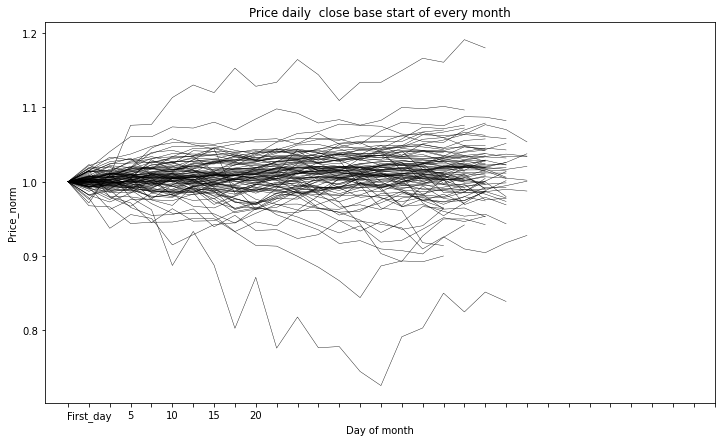

In [521]:
plot_days_trace(df, n_last=100, norm='nooo')
# A median line could be added as a proxy for the recent pattern.
# Hourly average deltas could be explored as an alternative representation.

**Reference:** https://dynamictimewarping.github.io/python/

### Compute the DTW distance matrix

In [ ]:
# Build a square distance matrix from the custom DTW distance function.
# Use scipy utilities to convert pairwise distances into a square matrix.

# K-medoids: https://scikit-learn-extra.readthedocs.io/en/stable/generated/sklearn_extra.cluster.KMedoids.html
# You have to precompute the distance matrix by DTW

**Define the DTW distance function used to build the distance matrix. The result is highly parameter-sensitive.**

In [742]:
# https://dynamictimewarping.github.io/py-api/html/api/dtw.dtw.html
# https://cran.r-project.org/web/packages/dtw/dtw.pdf
# DTW parameters require careful tuning and interpretation.
from dtw import *
def my_DTW_distance(ts1, ts2):
    alignment = dtw(ts1[np.logical_not(np.isnan(ts1))], # Remove missing values before DTW alignment.
                    ts2[np.logical_not(np.isnan(ts2))],
                    step_pattern=asymmetric,open_end=True, window_type='itakura')#, window_args={'window_size':4})
    return alignment.distance

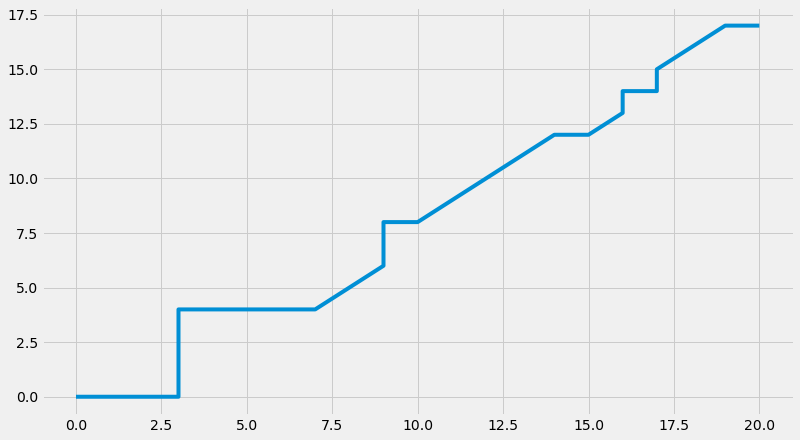

In [746]:
test=dtw(x=df.iloc[random.randint(1,df.shape[1])].dropna(), 
        y=df.iloc[random.randint(1,df.shape[1])].dropna(),
        open_end=True, window_type='sakoechiba', window_args={'window_size':3})

plt.plot(test.index1, test.index2)

**Compute the distance matrix**

In [747]:
from scipy.spatial.distance import squareform, pdist
dm = pd.DataFrame(squareform(pdist(df, metric=my_DTW_distance)), index=df.index, columns=df.index)

**Inspect the closest time series to a randomly selected reference series. The reference series is shown in black.**

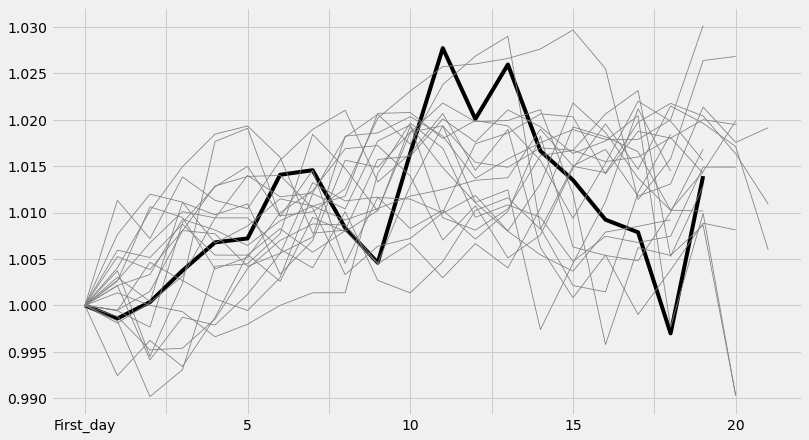

In [765]:
import random
test=dm.iloc[random.randint(1,dm.shape[0])].nsmallest(20)
for i, el in enumerate(list(test.index)):
    if i==0:
        df.loc[str(el)].plot.line(color='black')
    else:
        df.loc[str(el)].plot.line(color='grey', linewidth=0.8)

### Clustering with K-medoids

In [692]:
from sklearn_extra.cluster import KMedoids

In [766]:
# A list holds the SSE values for each k
sse = []
for k in range(1, 30):
    kmedoids = KMedoids(n_clusters=k, random_state=0, metric='precomputed').fit(dm)
    sse.append(kmedoids.inertia_)

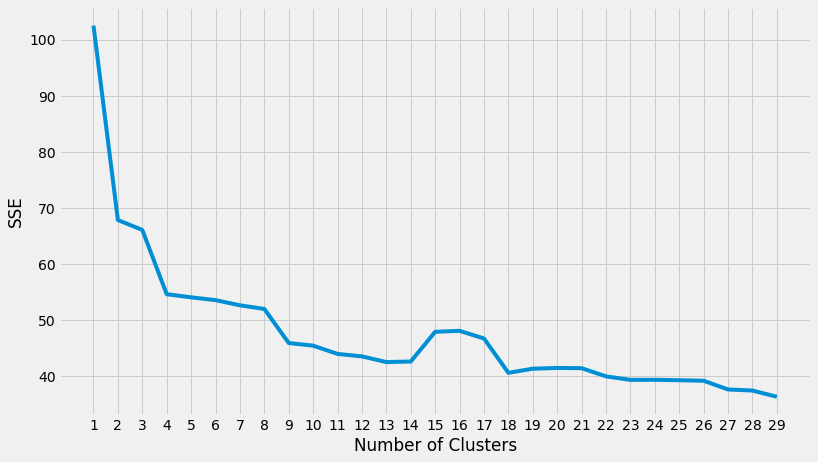

In [767]:
plt.style.use("fivethirtyeight")
plt.plot(range(1, 30), sse)
plt.xticks(range(1, 30))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [768]:
from kneed import KneeLocator
kl = KneeLocator(
    range(1, 30), sse, curve="convex", direction="decreasing"
)

kl.elbow

4

In [769]:
from sklearn.metrics import silhouette_score
# A list holds the silhouette coefficients for each k
silhouette_coefficients = []

# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, 30):
    kmedoids = KMedoids(n_clusters=k, random_state=0, metric='precomputed').fit(dm)
    score = silhouette_score(dm, kmedoids.labels_, metric='precomputed')
    silhouette_coefficients.append(score)

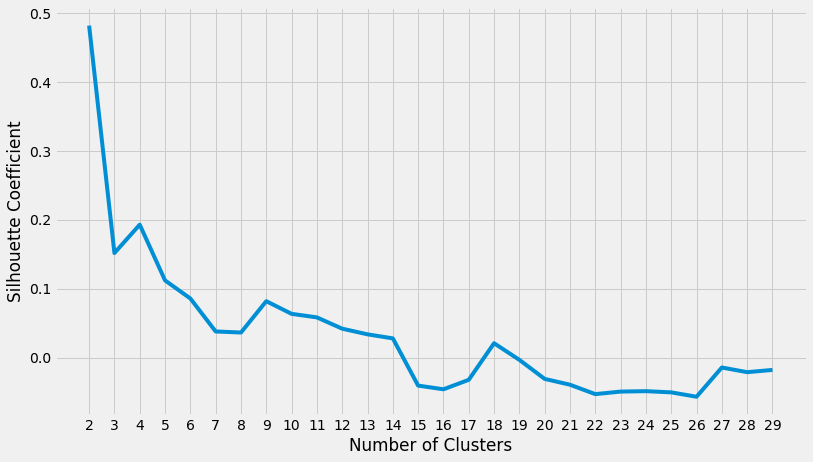

In [770]:
plt.style.use("fivethirtyeight")
plt.plot(range(2, 30), silhouette_coefficients)
plt.xticks(range(2, 30))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

In [771]:
kmedoids = KMedoids(n_clusters=4, random_state=0, metric='precomputed').fit(dm)

In [823]:
labs=kmedoids.labels_
unique, counts = np.unique(labs, return_counts=True)
dict(zip(unique, counts))

{0: 87, 1: 85, 2: 117, 3: 60}

In [831]:
df['Labels']= labs.astype('str')
med_i=kmedoids.medoid_indices_
med_i
enumerate(df[df.Labels==cluster].index)

In [832]:
for cluster in range(len(med_i)):
    print(cluster)
    for i, day in enumerate(df[df.Labels==cluster].index):
        print(i, day)

0
1
2
3


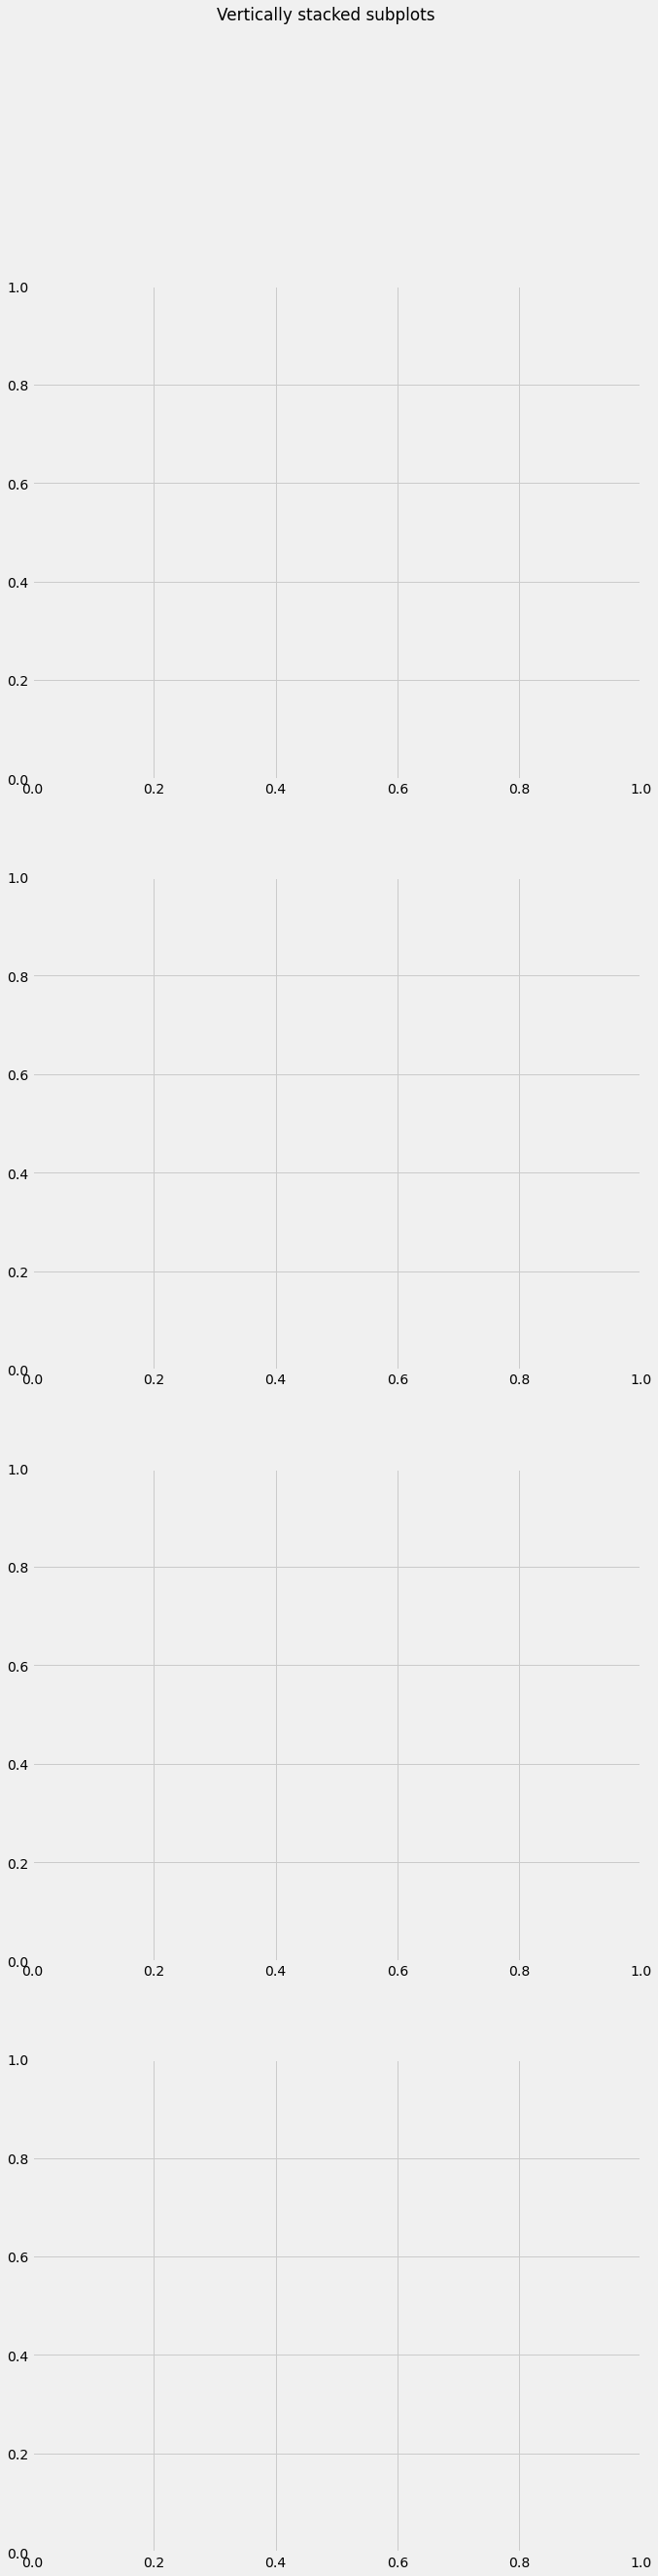

In [816]:
df['Labels']= labs.astype('str')
med_i=kmedoids.medoid_indices_
fig, axs = plt.subplots(len(med_i), figsize=(10,40))
fig.suptitle('Vertically stacked subplots')
for cluster in range(len(med_i)):
    for i, day in enumerate(df[df.Labels==cluster].index):
        if day==str(df.index[med_i[cluster]]): # Highlight the medoid series of each cluster.
            axs[cluster].plot(df[df.Labels==cluster].loc[day],color='red', linewidth=3 )#.plot.line(color='red', linewidth=3)
        else:
            axs[cluster].plot(df[df.Labels==cluster].loc[day], color='grey', linewidth=0.2)#.plot.line(color='grey', linewidth=0.1)
    

In [ ]:
# Calinski-Harabasz would need to be adapted using within- and between-cluster distances.

In [467]:
df['next_day_perf']= df.iloc[:,23].shift(-1)

In [468]:
df.dropna(inplace=True)

In [469]:
df.tail()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,Labels,next_day_perf
2022-01-07,1.0,0.998296,0.993427,0.970308,0.967923,0.971427,0.963949,0.968071,0.976935,0.984687,...,0.978018,0.974727,0.968092,0.969665,0.973072,0.971977,0.964243,0.964816,0,1.002725
2022-01-08,1.0,1.007625,1.007611,1.005880,1.008046,1.009749,1.008559,1.008350,1.009585,1.014368,...,0.994696,0.982573,0.978669,0.982308,0.985779,1.004873,1.008291,1.002725,4,1.004436
2022-01-09,1.0,1.003117,1.010059,1.003698,1.009589,1.002067,1.004652,1.002682,0.999686,0.995928,...,1.011116,1.009953,1.006892,1.024365,1.018226,1.014882,1.012611,1.004436,4,0.998994
2022-01-10,1.0,0.998822,1.001507,1.002460,1.007706,1.003981,1.001443,1.004246,0.998859,0.998361,...,1.000950,0.983753,0.993789,0.986445,0.996419,0.996405,0.993798,0.998994,3,1.021682
2022-01-11,1.0,1.002542,1.008399,1.010891,1.011529,1.006875,1.006755,1.009291,1.004048,1.003881,...,1.021107,1.017372,1.022297,1.027487,1.023382,1.020006,1.021296,1.021682,4,1.027461


In [470]:
import qgrid

qgrid.show_grid(df.groupby(['Labels'])['next_day_perf'].describe())

QgridWidget(grid_options={'fullWidthRows': True, 'syncColumnCellResize': True, 'forceFitColumns': True, 'defau…

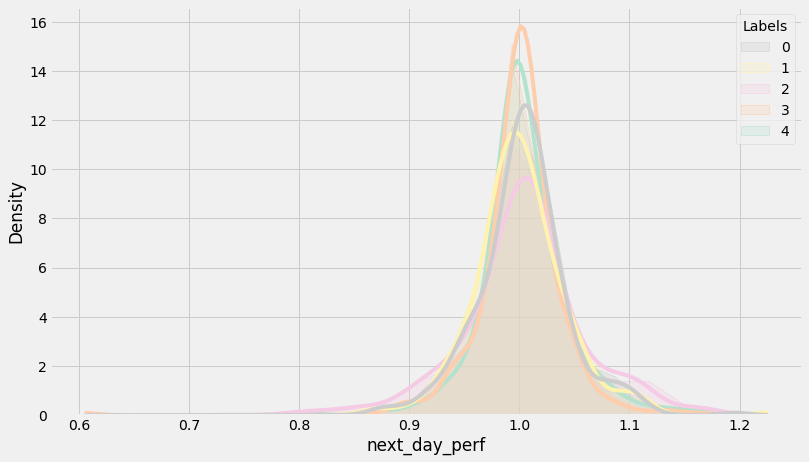

In [471]:
import seaborn as sns
sns.color_palette("flare", as_cmap=True)
sns.histplot(data=df, x="next_day_perf", hue="Labels",  kde=True,  bins=20,  
             stat="density", common_norm=False, element="poly",palette='Pastel2_r')

In [386]:
df['Green']= np.where(df.next_day_perf >= 1 , 1, 0)

In [387]:
pd.crosstab(df.Labels, df.Green, normalize='index')

Green,0,1
Labels,,
0,0.474227,0.525773
1,0.413462,0.586538
2,0.436364,0.563636
3,0.421296,0.578704
4,0.519774,0.480226
5,0.504587,0.495413
6,0.449438,0.550562
7,0.507042,0.492958
8,0.514019,0.485981


### Notes

1. Daily intraday clustering appears noisy; a weekly aggregation may be more informative.
2. The fit looks promising, but the cluster labels should be interpreted cautiously.
3. DTW parameter choices can strongly affect the resulting clusters.


## Weekly time series built from daily data

In [1]:
%run binance_get_data.py

moneta:
btcusdt
timeframe:
1d
inizio "%d-%m-%Y" :
01-01-2017
fine
17-01-2022


100%|███████████████████████████████████████████████████████████████████████████| 1615/1615 [00:00<00:00, 69615.54it/s]

creato file: 
 C:\Users\gelso\python_trading\BTCUSDT_1d_01-01-2017_17-01-2022.csv


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt

df= pd.read_csv('BTCUSDT_1d_01-01-2017_17-01-2022.csv' ,header=0, usecols=[0,1,4])
# Skip rows at the start/end to obtain regular observations for each period.
df.set_index(pd.to_datetime(df.datetime), inplace=True)
df.drop(['datetime'], axis=1, inplace=True)
# open_day_hour = df.pop('open')

df['dayofweek']= df.index.day_of_week

In [2]:
seq=np.where(df.dayofweek==6)
seq=seq[0].tolist()
seq.insert(0, 0)

In [3]:
df_resample=[]
for idx, extr in enumerate(seq):
    #df.iloc[:i,:]
    if (idx==0 ) or (idx==231):
        pass
    else:
        list_row= [None] *7
        list_row[0]=1 # First element.
        open_monday= df.iloc[extr, 1]
        list_row[1:7]=df.iloc[extr+3:seq[idx+1]+2 , 0] / open_monday # divide by first open
        #    
        df_resample.append(list_row)

df2= pd.DataFrame(df_resample)

new_index=df.index[df.index.weekday==0]

df=df2.set_index(new_index[:-1])

In [4]:
plot_days_trace(df, n_last=10, norm='nooo')

NameError: name 'plot_days_trace' is not defined

In [5]:
from dtw import *
def my_DTW_distance(ts1, ts2):
    alignment = dtw(ts1,ts2, keep_internals=True, distance_only=True, step_pattern= 'symmetric1', # Asymmetric step pattern.
                    window_type='sakoechiba', window_args={'window_size':2} )
                   #open_end=False)
    return alignment.distance

Importing the dtw module. When using in academic works please cite:
  T. Giorgino. Computing and Visualizing Dynamic Time Warping Alignments in R: The dtw Package.
  J. Stat. Soft., doi:10.18637/jss.v031.i07.



In [6]:
from scipy.spatial.distance import squareform, pdist
dm = pd.DataFrame(squareform(pdist(df, metric=my_DTW_distance)), index=df.index, columns=df.index)

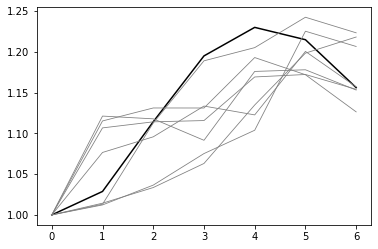

In [7]:
import random
test=dm.iloc[random.randint(1,len(df))].nsmallest(8)
for i, el in enumerate(list(test.index)):
    if i==0:
        df.loc[str(el)][0:24].plot.line(color='black')
    else:
        df.loc[str(el)][0:24].plot.line(color='grey', linewidth=0.8)
        
# Visual inspection suggests that raw price levels can dominate the similarity measure.
# This is a problem if the objective is to compare shapes rather than price levels.
# Possible alternatives considered:
# - standardizing each row;
# - using returns instead of raw close prices;
# - using cumulative returns;
# - indexing each series to the first price of the period, as in the reference approach. 

In [8]:
from sklearn_extra.cluster import KMedoids

In [9]:
# A list holds the SSE values for each k
sse = []
for k in range(1, 30):
    kmedoids = KMedoids(n_clusters=k, random_state=0, metric='precomputed').fit(dm)
    sse.append(kmedoids.inertia_)

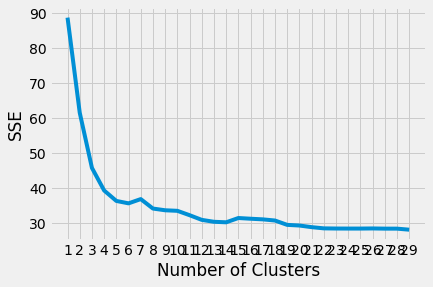

In [10]:
plt.style.use("fivethirtyeight")
plt.plot(range(1, 30), sse)
plt.xticks(range(1, 30))
plt.xlabel("Number of Clusters")
plt.ylabel("SSE")
plt.show()

In [11]:
from kneed import KneeLocator
kl = KneeLocator(
    range(1, 30), sse, curve="convex", direction="decreasing"
)

kl.elbow

5

In [12]:
from sklearn.metrics import silhouette_score
# A list holds the silhouette coefficients for each k
silhouette_coefficients = []

# Notice you start at 2 clusters for silhouette coefficient
for k in range(2, 30):
    kmedoids = KMedoids(n_clusters=k, random_state=0, metric='precomputed').fit(dm)
    score = silhouette_score(dm, kmedoids.labels_, metric='precomputed')
    silhouette_coefficients.append(score)

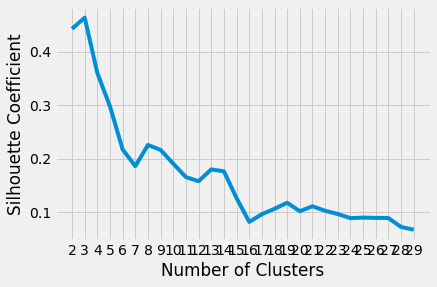

In [13]:
plt.style.use("fivethirtyeight")
plt.plot(range(2, 30), silhouette_coefficients)
plt.xticks(range(2, 30))
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Coefficient")
plt.show()

In [14]:
kmedoids = KMedoids(n_clusters=3, random_state=0, metric='precomputed').fit(dm)

In [15]:
labs=kmedoids.labels_
unique, counts = np.unique(labs, return_counts=True)
dict(zip(unique, counts))

{0: 43, 1: 72, 2: 115}

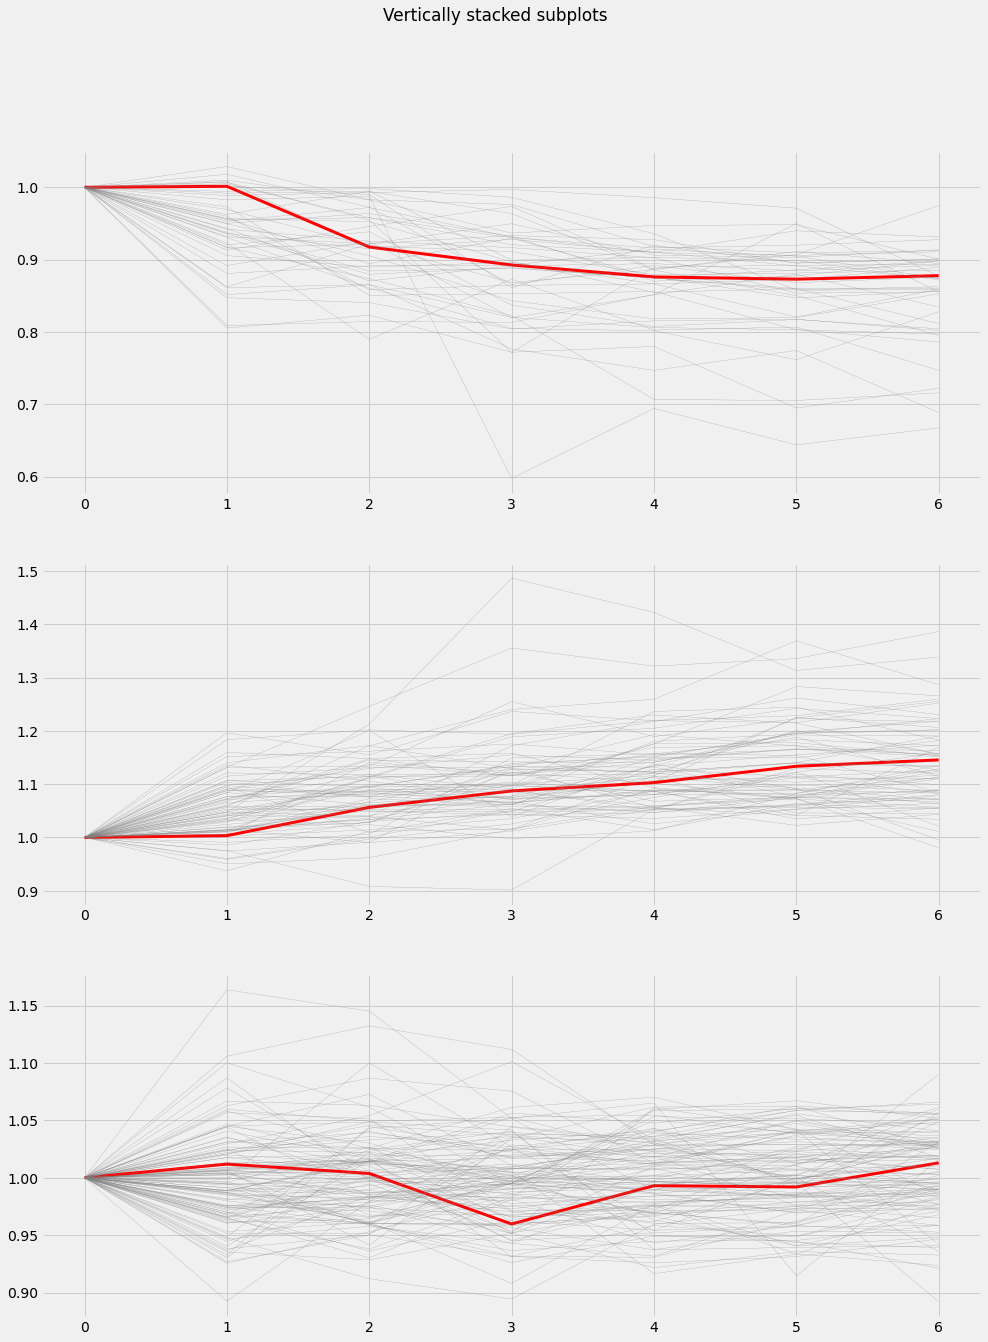

In [16]:
df_info= df.copy()
df_info['Labels']= labs
df['Labels']= labs
med_i=kmedoids.medoid_indices_
fig, axs = plt.subplots(len(med_i), figsize=(15,20))
fig.suptitle('Vertically stacked subplots')
for cluster in range(len(med_i)):
    for i, day in enumerate(df_info[df_info.Labels==cluster].index):
        if day==df_info.index[med_i[cluster]]:
            axs[cluster].plot(df_info[df_info.Labels==cluster].loc[day][0:7],color='red', linewidth=3 )#.plot.line(color='red', linewidth=3)
        else:
            axs[cluster].plot(df_info[df_info.Labels==cluster].loc[day][0:7], color='grey', linewidth=0.2)#.plot.line(color='grey', linewidth=0.1)
    

In [17]:
df_info['next_week_perf']= df.iloc[:,6].shift(-1)

In [18]:
df_info.dropna(inplace=True)

In [19]:
df_info.tail()

,0,1,2,3,4,5,6,Labels,next_week_perf
datetime,,,,,,,,,
2021-12-06,1,1.024144,1.021760,0.962337,0.954333,0.999872,1.013312,2,0.932619
2021-12-13,1,0.965698,0.976247,0.951622,0.921683,0.935681,0.932619,2,1.087707
2021-12-20,1,1.047264,1.040850,1.089063,1.088660,1.079656,1.087707,1,0.931280
2021-12-27,1,0.936352,0.915100,0.928024,0.910221,0.939876,0.931280,0,0.885346
2022-01-03,1,0.969247,0.918897,0.911097,0.879041,0.881436,0.885346,0,1.028832


In [20]:
import qgrid

qgrid.show_grid(df_info.groupby(['Labels'])['next_week_perf'].describe())

QgridWidget(grid_options={'fullWidthRows': True, 'syncColumnCellResize': True, 'forceFitColumns': True, 'defau…

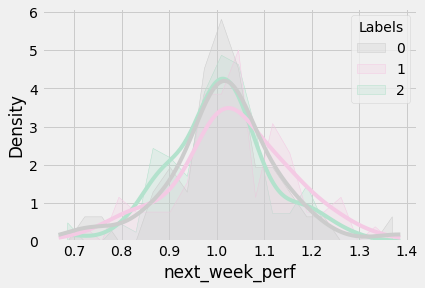

In [21]:
import seaborn as sns
sns.color_palette("flare", as_cmap=True)
sns.histplot(data=df_info, x="next_week_perf", hue="Labels",  kde=True,  bins=20,  
             stat="density", common_norm=False, element="poly",palette='Pastel2_r')

In [22]:
df_info['Green']= np.where(df_info.next_week_perf >= 1 , 1, 0)

In [23]:
pd.crosstab(df_info.Labels, df_info.Green, normalize='index')

Green,0,1
Labels,,
0,0.372093,0.627907
1,0.388889,0.611111
2,0.473684,0.526316


In [24]:
df.tail(1)# Last available weekly classification; label 2 was interpreted as no-position in this exploratory setup.

,0,1,2,3,4,5,6,Labels
datetime,,,,,,,,
2022-01-10,1,1.020654,1.048681,1.016571,1.028553,1.029134,1.028832,2


In [40]:
data = (df_info[['next_week_perf', 'Labels']].values)

In [41]:
data

array([[1.04524119, 2.        ],
       [0.92116795, 1.        ],
       [0.89338243, 2.        ],
       [0.98919727, 0.        ],
       [1.20217922, 2.        ],
       [1.05972849, 1.        ],
       [1.23060345, 2.        ],
       [1.04641164, 1.        ],
       [1.03075452, 2.        ],
       [1.19045767, 2.        ],
       [0.79508946, 1.        ],
       [1.38652012, 0.        ],
       [1.13560587, 1.        ],
       [1.22320175, 1.        ],
       [1.33862169, 1.        ],
       [1.2657762 , 1.        ],
       [0.71579988, 1.        ],
       [1.01597407, 0.        ],
       [1.18244563, 2.        ],
       [0.83454829, 1.        ],
       [0.85565926, 0.        ],
       [1.03035126, 0.        ],
       [0.68855424, 2.        ],
       [0.98521774, 0.        ],
       [1.28660273, 2.        ],
       [0.92358691, 1.        ],
       [1.20072993, 2.        ],
       [0.82792618, 1.        ],
       [0.85896469, 0.        ],
       [1.03420639, 0.        ],
       [0.

In [47]:
from scipy.stats import bootstrap
res = bootstrap(data[0], np.mean, confidence_level=0.9,random_state=33, method='BCa')
# print(res.confidence_interval)

#print (df_info.groupby('Labels')['next_week_perf'].apply(lambda x:bootstrap(data, np.mean, confidence_level=0.9,
                #random_state=33)))

ValueError: each sample in `data` must contain two or more observations along `axis`.

### Notes

1. In terms of the fraction of positive next-week performance, one cluster appears more favorable.
2. Daily shape information alone may not be sufficient to stratify future weekly performance.
3. The result is exploratory and sensitive to DTW and clustering parameters.
